Airline Delay Analysis

In [ ]:
# Install PySpark (Colab only)

!pip install pyspark


In [ ]:
# Import libraries

from pyspark.sql import SparkSession
from pyspark.sql.functions import *
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
# Create Spark Session

spark = SparkSession.builder \
    .appName("Airline Delay Analysis") \
    .getOrCreate()

In [ ]:
# Load dataset

df = spark.read.csv(
    "/content/Airline_Delay_Cause.csv",
    header=True,
    inferSchema=True
)

Dataset Loading

In [ ]:
# View schema

df.printSchema()

# View sample records

df.show(5)

root
 |-- year: integer (nullable = true)
 |-- month: integer (nullable = true)
 |-- carrier: string (nullable = true)
 |-- carrier_name: string (nullable = true)
 |-- airport: string (nullable = true)
 |-- airport_name: string (nullable = true)
 |-- arr_flights: integer (nullable = true)
 |-- arr_del15: integer (nullable = true)
 |-- carrier_ct: double (nullable = true)
 |-- weather_ct: double (nullable = true)
 |-- nas_ct: double (nullable = true)
 |-- security_ct: double (nullable = true)
 |-- late_aircraft_ct: double (nullable = true)
 |-- arr_cancelled: integer (nullable = true)
 |-- arr_diverted: integer (nullable = true)
 |-- arr_delay: integer (nullable = true)
 |-- carrier_delay: integer (nullable = true)
 |-- weather_delay: integer (nullable = true)
 |-- nas_delay: integer (nullable = true)
 |-- security_delay: integer (nullable = true)
 |-- late_aircraft_delay: integer (nullable = true)

+----+-----+-------+-------------+-------+--------------------+-----------+---------+---

Null Value Check

In [ ]:
# Count null values in each column

null_counts = df.select([
    count(when(col(c).isNull(), c)).alias(c)
    for c in df.columns
])

null_counts.show()

+----+-----+-------+------------+-------+------------+-----------+---------+----------+----------+------+-----------+----------------+-------------+------------+---------+-------------+-------------+---------+--------------+-------------------+
|year|month|carrier|carrier_name|airport|airport_name|arr_flights|arr_del15|carrier_ct|weather_ct|nas_ct|security_ct|late_aircraft_ct|arr_cancelled|arr_diverted|arr_delay|carrier_delay|weather_delay|nas_delay|security_delay|late_aircraft_delay|
+----+-----+-------+------------+-------+------------+-----------+---------+----------+----------+------+-----------+----------------+-------------+------------+---------+-------------+-------------+---------+--------------+-------------------+
|   0|    0|      0|           0|      0|           0|        657|      950|       657|       657|   657|        657|             657|          657|         657|      657|          657|          657|      657|           657|                657|
+----+-----+-------+

Question 1: How Have Overall Flight Delays Changed Over Time?

PySpark Aggregation

In [ ]:
q1 = df.groupBy("year","month") \
    .agg(
        sum("arr_del15").alias("total_delayed"),
        sum("arr_flights").alias("total_flights")
    ) \
    .withColumn(
        "delay_rate",
        col("total_delayed")/col("total_flights")
    ) \
    .orderBy("year","month")

q1.show()

+----+-----+-------------+-------------+-------------------+
|year|month|total_delayed|total_flights|         delay_rate|
+----+-----+-------------+-------------+-------------------+
|2003|    6|        89441|       536496|0.16671326533655423|
|2003|    7|       104579|       558568| 0.1872269804213632|
|2003|    8|       106326|       556984|0.19089596828634214|
|2003|    9|        67386|       527714|0.12769416767415684|
|2003|   10|        69394|       552370|0.12562955989644622|
|2003|   11|        96177|       528171|0.18209443532492317|
|2003|   12|       120668|       555495|0.21722607764246302|
|2004|    1|       128236|       583987| 0.2195870798493802|
|2004|    2|       114517|       553876|0.20675566372256607|
|2004|    3|       104031|       601412|0.17297792528250183|
|2004|    4|        93754|       582970| 0.1608213115597715|
|2004|    5|       121019|       594457|0.20357906459171984|
|2004|    6|       148726|       588792|0.25259514395576027|
|2004|    7|       13599

Visualization

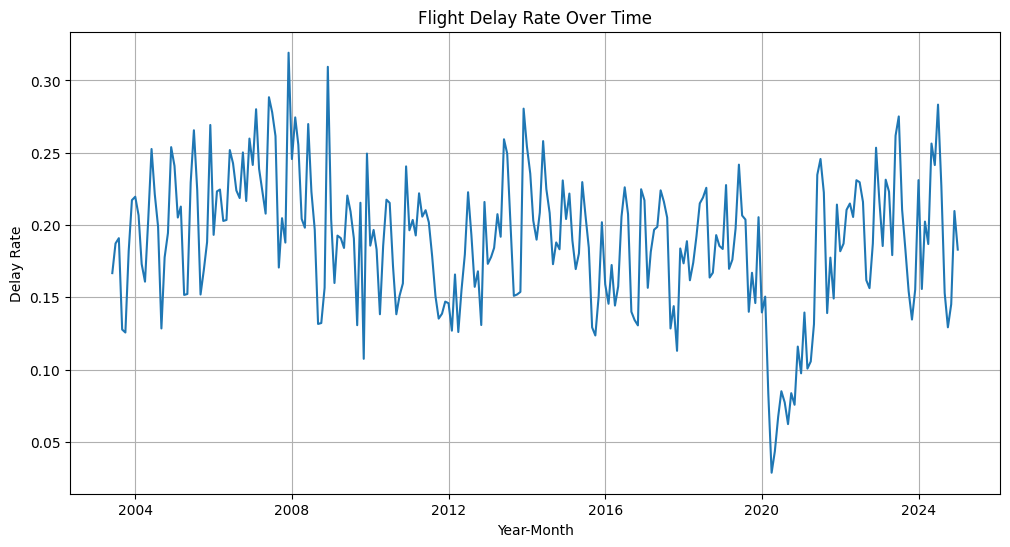

In [ ]:
pdf = q1.toPandas()

pdf["date"] = pd.to_datetime(
    pdf["year"].astype(str) + "-" +
    pdf["month"].astype(str) + "-01"
)

plt.figure(figsize=(12,6))

plt.plot(pdf["date"], pdf["delay_rate"])

plt.title("Flight Delay Rate Over Time")
plt.xlabel("Year-Month")
plt.ylabel("Delay Rate")
plt.grid(True)

plt.show()

Question 2: Which Airlines Have the Highest Percentage of Delayed Flights?

PySpark Aggregation

In [ ]:
q2 = df.groupBy("carrier_name") \
    .agg(
        sum("arr_del15").alias("delayed"),
        sum("arr_flights").alias("flights")
    ) \
    .withColumn(
        "delay_rate",
        col("delayed")/col("flights")
    ) \
    .orderBy(desc("delay_rate"))

q2.show()

+--------------------+-------+-------+-------------------+
|        carrier_name|delayed|flights|         delay_rate|
+--------------------+-------+-------+-------------------+
|Peninsula Airways...|   1015|   3227|0.31453362255965295|
|   Frontier Airlines| 272946|1041066| 0.2621793430964031|
|Trans States Airl...|  43815| 178098|0.24601623825085064|
|Atlantic Southeas...| 618201|2526762|0.24466134918919946|
|     JetBlue Airways|1151344|4720734|0.24389088645960563|
|Commutair Aka Cha...|  68214| 280544|0.24314902475191058|
|       Allegiant Air| 184022| 774867|0.23748849802611288|
|    Spirit Air Lines|  97462| 412396|0.23633109923471615|
|         Comair Inc.| 394146|1765828|0.22320746981019668|
|Northwest Airline...| 610029|2767549|0.22042211357414088|
|Continental Air L...| 537252|2447164|0.21954066012739645|
|American Eagle Ai...|1129165|5184465| 0.2177977862711003|
|Frontier Airlines...| 241699|1120723|0.21566346010566392|
|ExpressJet Airlin...|1536141|7148719|0.2148833937940489

Visualization

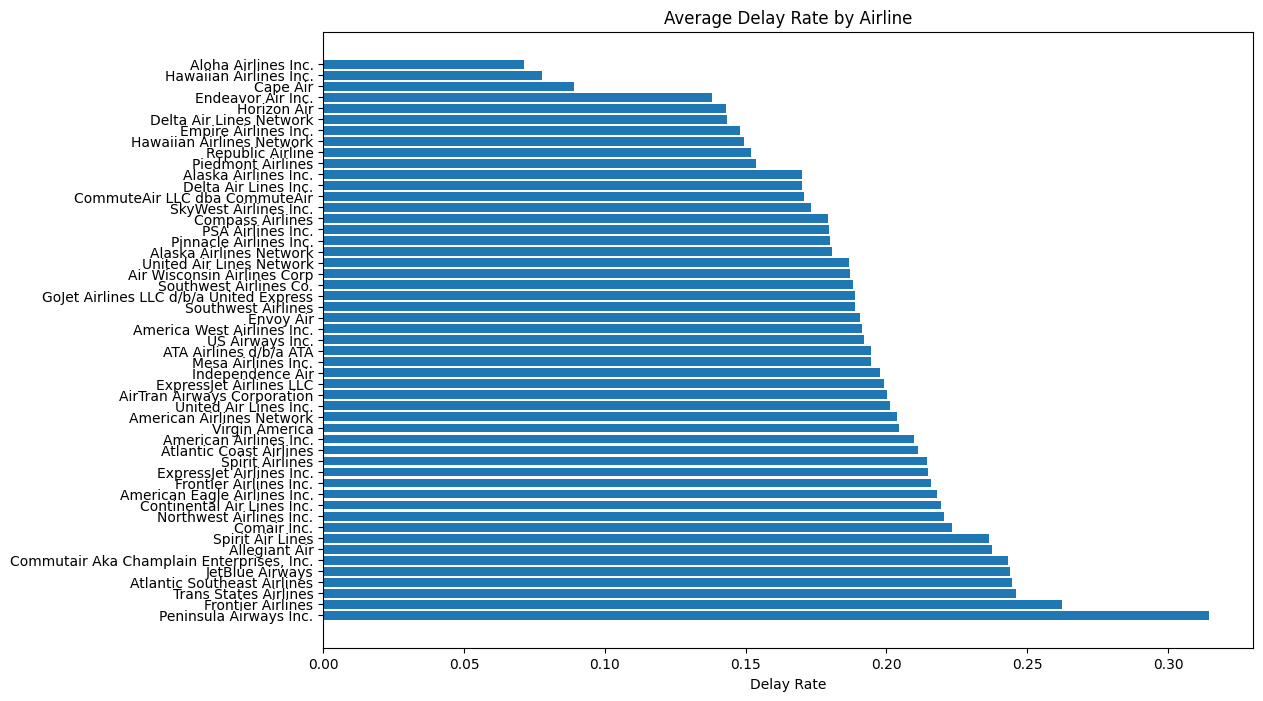

In [ ]:
pdf = q2.toPandas()

plt.figure(figsize=(12,8))

plt.barh(
    pdf["carrier_name"],
    pdf["delay_rate"]
)

plt.title("Average Delay Rate by Airline")
plt.xlabel("Delay Rate")

plt.show()

Question 3: Which Airlines Experience the Most Carrier-Caused Delays?



PySpark Aggregation

In [ ]:
q3 = df.groupBy("carrier_name") \
    .agg(
        sum("carrier_ct").alias("carrier_delay_count")
    ) \
    .orderBy(desc("carrier_delay_count"))

q3.show()

+--------------------+-------------------+
|        carrier_name|carrier_delay_count|
+--------------------+-------------------+
|SkyWest Airlines ...|  873465.6399999987|
|Southwest Airline...|  862382.4499999996|
|  Southwest Airlines|  572138.8499999996|
|American Airlines...|  557837.3600000013|
|Delta Air Lines Inc.|  486205.5400000016|
|American Airlines...|  394088.7200000002|
|United Air Lines ...|  383910.7000000003|
|ExpressJet Airlin...|  370796.6800000004|
|     JetBlue Airways|  362771.3800000007|
|Delta Air Lines N...| 338247.55999999994|
|American Eagle Ai...| 280421.53999999946|
|     US Airways Inc.| 272573.00999999966|
|United Air Lines ...|  228146.0799999994|
|Atlantic Southeas...| 218409.84999999977|
|  Mesa Airlines Inc.| 212565.42000000004|
|Northwest Airline...| 198141.91999999929|
|         Comair Inc.| 146193.59000000003|
|Alaska Airlines Inc.| 113977.73999999992|
|Continental Air L...| 112686.42999999982|
|           Envoy Air| 108344.07999999973|
+----------

Visualization

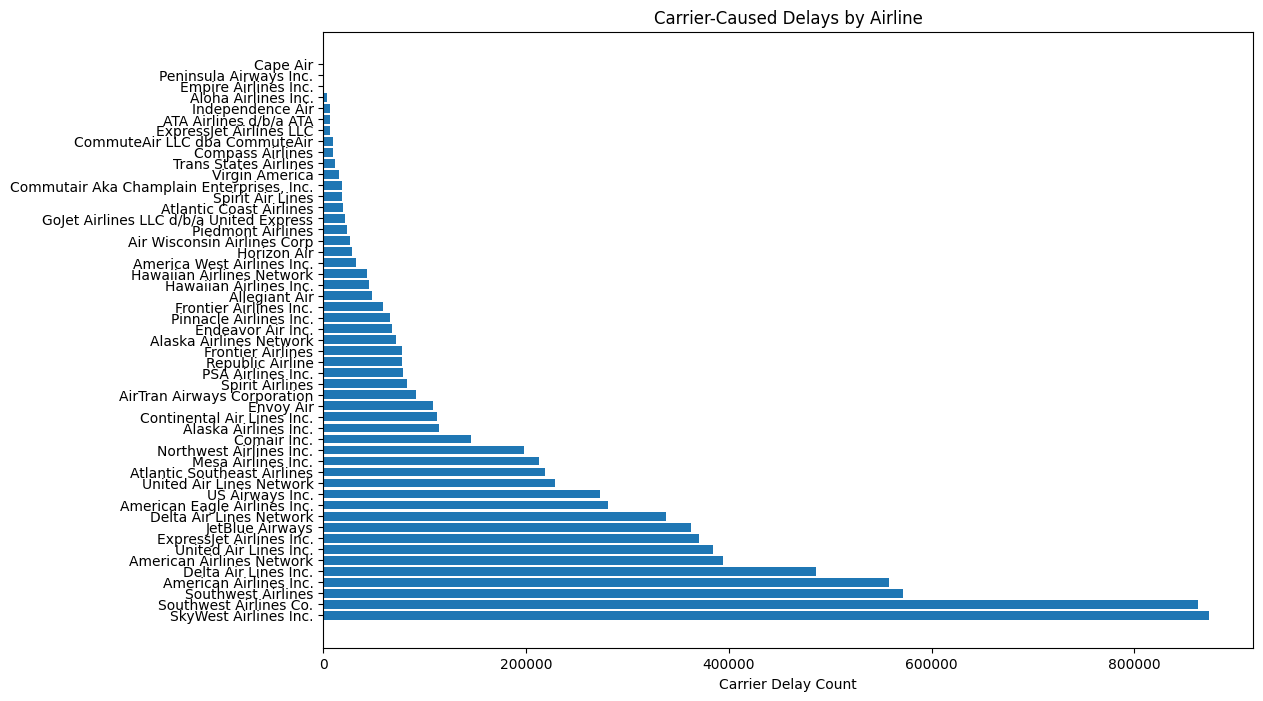

In [ ]:
pdf = q3.toPandas()

plt.figure(figsize=(12,8))

plt.barh(
    pdf["carrier_name"],
    pdf["carrier_delay_count"]
)

plt.title("Carrier-Caused Delays by Airline")
plt.xlabel("Carrier Delay Count")

plt.show()

Question 4: Which Airports Have the Highest Delay Rates?

PySpark Aggregation

In [ ]:
q4 = df.groupBy("airport_name") \
    .agg(
        sum("arr_del15").alias("delayed"),
        sum("arr_flights").alias("flights")
    ) \
    .withColumn(
        "delay_rate",
        col("delayed")/col("flights")
    ) \
    .orderBy(desc("delay_rate"))

q4.show()

+--------------------+-------+-------+-------------------+
|        airport_name|delayed|flights|         delay_rate|
+--------------------+-------+-------+-------------------+
|Youngstown/Warren...|      2|      2|                1.0|
|Pinehurst/Souther...|    133|    317| 0.4195583596214511|
|Unalaska, AK: Una...|    770|   2074| 0.3712632594021215|
|Topeka, KS: Topek...|    164|    449|0.36525612472160357|
|Cold Bay, AK: Col...|     90|    262| 0.3435114503816794|
|Wilmington, DE: N...|    688|   2121| 0.3243752946723244|
|Salem, OR: McNary...|    281|    880|0.31931818181818183|
|Macon, GA: Middle...|   2050|   6483|0.31621163041801637|
|Aguadilla, PR: Ra...|   9692|  33747| 0.2871958988947166|
|Stockton, CA: Sto...|    619|   2160| 0.2865740740740741|
|Presque Isle/Houl...|   1078|   3780| 0.2851851851851852|
|North Bend/Coos B...|   2698|   9572|0.28186376932720436|
|Punta Gorda, FL: ...|  11681|  41723| 0.2799654866620329|
|Kinston, NC: Kins...|    407|   1456|0.2795329670329670

Visualization

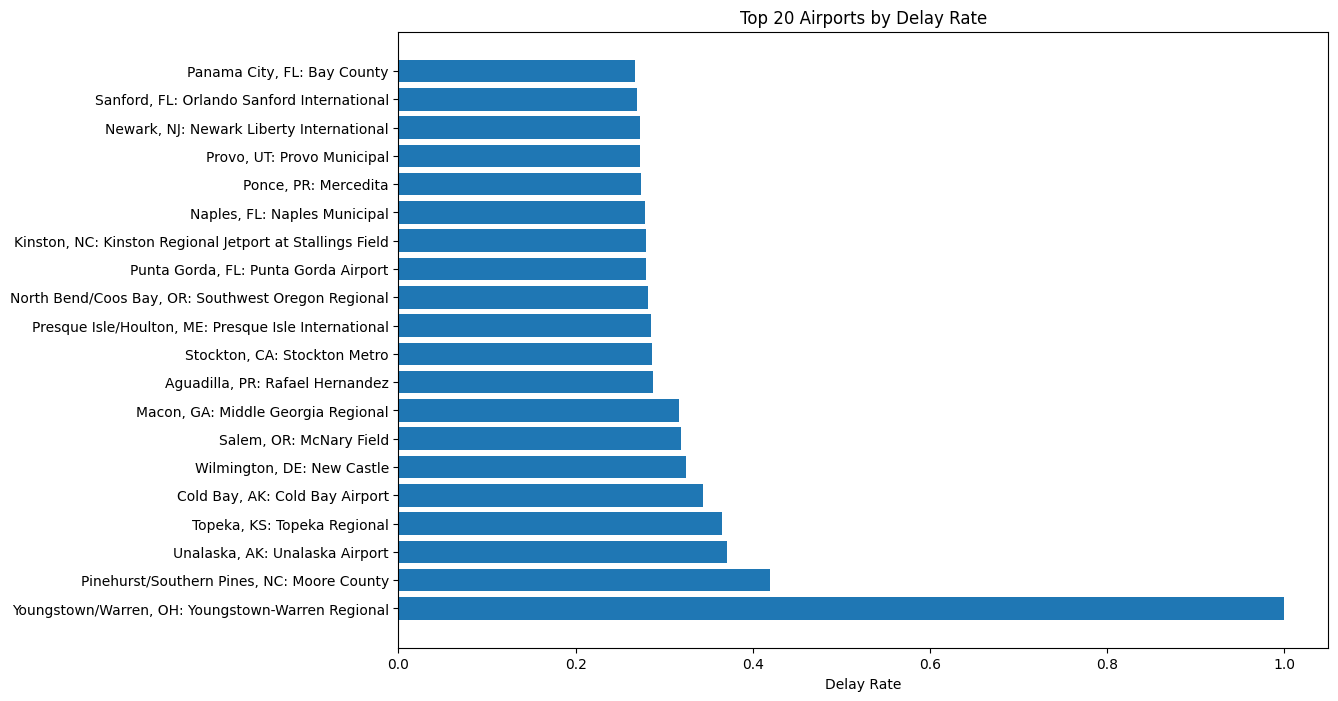

In [ ]:
pdf = q4.limit(20).toPandas()

plt.figure(figsize=(12,8))

plt.barh(
    pdf["airport_name"],
    pdf["delay_rate"]
)

plt.title("Top 20 Airports by Delay Rate")
plt.xlabel("Delay Rate")

plt.show()

Question 5: What Are the Dominant Causes of Delays Across All Flights?

PySpark Aggregation

In [ ]:
q5 = df.groupBy("year") \
    .agg(
        sum("carrier_ct").alias("carrier"),
        sum("weather_ct").alias("weather"),
        sum("nas_ct").alias("nas"),
        sum("security_ct").alias("security"),
        sum("late_aircraft_ct").alias("late_aircraft")
    ) \
    .orderBy("year")
q5.show()

+----+------------------+------------------+------------------+------------------+------------------+
|year|           carrier|           weather|               nas|          security|     late_aircraft|
+----+------------------+------------------+------------------+------------------+------------------+
|2003|164663.44999999992|26807.649999999947| 281803.4000000005|2189.2999999999984|178507.31000000026|
|2004| 363577.4500000017| 71606.14000000026| 561139.1199999994| 4648.730000000007|420421.50000000006|
|2005| 413227.0199999995| 66681.77999999984| 539380.8100000045| 3785.939999999994|442989.78999999893|
|2006| 457816.6699999997|  66538.1499999999| 556312.9000000024| 5903.730000000009| 528966.0600000013|
|2007| 520596.5899999985| 72306.87999999995| 598257.7999999961| 4939.479999999995| 607928.2500000012|
|2008|411600.85999999975| 56639.44000000007| 549861.1200000002|           3254.29| 503380.7199999952|
|2009|323742.69999999925| 41865.17000000006|450644.75000000047| 2327.930000000003|

Visualization

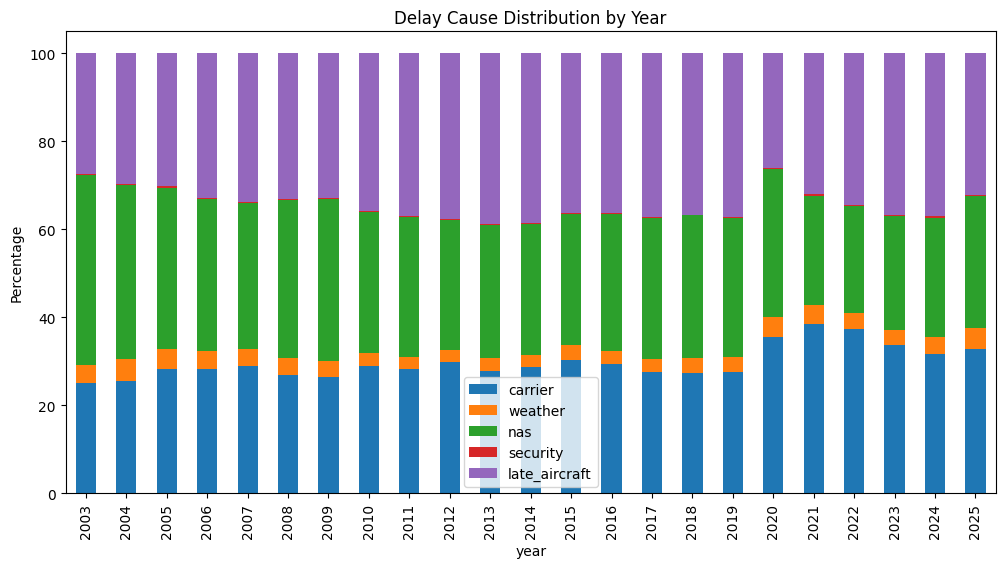

In [ ]:
pdf = q5.toPandas()

cause_cols = [
    "carrier",
    "weather",
    "nas",
    "security",
    "late_aircraft"
]

pdf[cause_cols] = (
    pdf[cause_cols]
    .div(pdf[cause_cols].sum(axis=1), axis=0)
    * 100
)

pdf.set_index("year")[cause_cols].plot(
    kind="bar",
    stacked=True,
    figsize=(12,6)
)

plt.title("Delay Cause Distribution by Year")
plt.ylabel("Percentage")
plt.show()

Question 6: How Do Causes of Delays Vary by Season?

PySpark Aggregation

In [ ]:
q5 = df.groupBy("year") \
    .agg(
        sum("carrier_ct").alias("carrier"),
        sum("weather_ct").alias("weather"),
        sum("nas_ct").alias("nas"),
        sum("security_ct").alias("security"),
        sum("late_aircraft_ct").alias("late_aircraft")
    ) \
    .orderBy("year")
q5.show()

+----+------------------+------------------+------------------+------------------+------------------+
|year|           carrier|           weather|               nas|          security|     late_aircraft|
+----+------------------+------------------+------------------+------------------+------------------+
|2003|164663.44999999992|26807.649999999947| 281803.4000000005|2189.2999999999984|178507.31000000026|
|2004| 363577.4500000017| 71606.14000000026| 561139.1199999994| 4648.730000000007|420421.50000000006|
|2005| 413227.0199999995| 66681.77999999984| 539380.8100000045| 3785.939999999994|442989.78999999893|
|2006| 457816.6699999997|  66538.1499999999| 556312.9000000024| 5903.730000000009| 528966.0600000013|
|2007| 520596.5899999985| 72306.87999999995| 598257.7999999961| 4939.479999999995| 607928.2500000012|
|2008|411600.85999999975| 56639.44000000007| 549861.1200000002|           3254.29| 503380.7199999952|
|2009|323742.69999999925| 41865.17000000006|450644.75000000047| 2327.930000000003|

Visualization

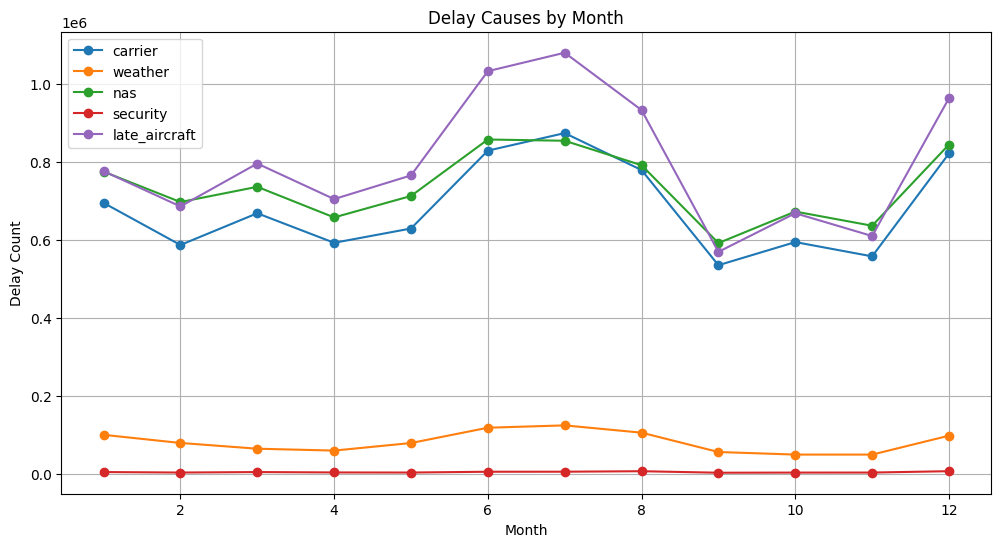

In [ ]:
pdf = q6.toPandas()

plt.figure(figsize=(12,6))

for c in [
    "carrier",
    "weather",
    "nas",
    "security",
    "late_aircraft"
]:
    plt.plot(pdf["month"], pdf[c], marker="o", label=c)

plt.legend()
plt.title("Delay Causes by Month")
plt.xlabel("Month")
plt.ylabel("Delay Count")
plt.grid(True)

plt.show()

Question 7: Which Months Have the Highest and Lowest Delay Percentages?

PySpark Aggregation

In [ ]:
q8 = df.groupBy("carrier_name") \
    .agg(
        sum("arr_del15").alias("delayed"),
        sum("arr_flights").alias("flights")
    ) \
    .withColumn(
        "delay_rate",
        col("delayed")/col("flights")
    ) \
    .orderBy("carrier_name")
q8.show()

+--------------------+-------+--------+-------------------+
|        carrier_name|delayed| flights|         delay_rate|
+--------------------+-------+--------+-------------------+
|ATA Airlines d/b/...|  35298|  181463|0.19451899285253743|
|Air Wisconsin Air...|  97971|  523646|0.18709395278489666|
|AirTran Airways C...| 486307| 2427762| 0.2003108212419504|
|Alaska Airlines Inc.| 392718| 2309954|0.17001117771176397|
|Alaska Airlines N...| 284479| 1575469|0.18056781821794018|
|       Allegiant Air| 184022|  774867|0.23748849802611288|
| Aloha Airlines Inc.|   6374|   89547|0.07118049739243079|
|America West Airl...|  96342|  503162|0.19147312396405133|
|American Airlines...|1984814| 9457537|0.20986584562132826|
|American Airlines...|1231294| 6043869| 0.2037261231174931|
|American Eagle Ai...|1129165| 5184465| 0.2177977862711003|
|Atlantic Coast Ai...|  79078|  374247|0.21129895496824289|
|Atlantic Southeas...| 618201| 2526762|0.24466134918919946|
|            Cape Air|    148|    1661|0

Visualization

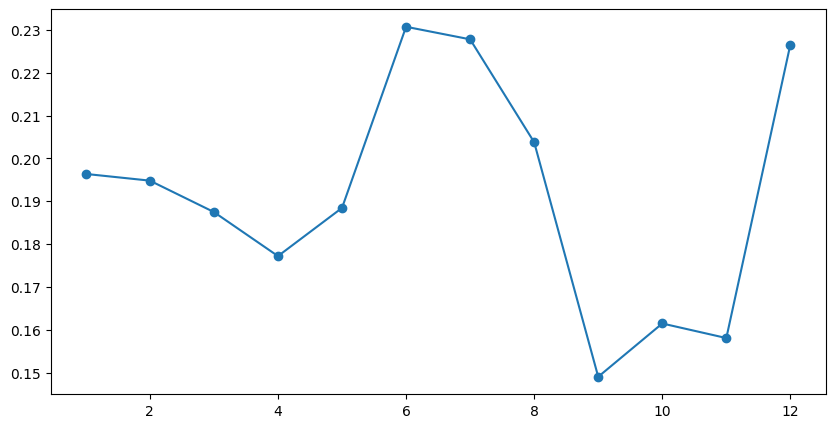

In [ ]:
pdf = q7.toPandas()

plt.figure(figsize=(10,5))

plt.plot(
    pdf["month"],
    pdf["delay_rate"],
    marker="o"
)

Conclusion

This project analyzed airline delay data using PySpark by performing data preprocessing, aggregation, and visualization. The results showed that delay rates vary across airlines, airports, months, and years. Carrier delays, weather conditions, and late-aircraft delays were identified as major contributors to flight disruptions. Overall, the analysis demonstrates how PySpark can efficiently process large datasets and provide valuable insights into airline performance and delay patterns.